In [1]:
# First physical cell: only standard-library checks before teaching imports.
from pathlib import Path
import hashlib, json
BASE = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'data_integrity.json').is_file() and (p / 'experiment.py').is_file()), None)
if BASE is None: raise ValueError('Run within the complete ML049 directory')
EXPECTED = {'data/protocol.json': '25d2affebd5b83daf3d29eff35eda04acd3378445370a950f113e55d8eb112fc', 'data/population.csv': '7339f0a1cd8029af6fc5fefd444225a322345c0539a566d1c91bf500e5129e65', 'data/hypotheses.csv': '610ba1964cabb28bd3f9da0c644d216bcb9a25b4d1e0b1304f2567660e26392f', 'data/hand_sample.csv': '3c7cc010c9754a4b4b12f0db7b6c37059f1de290caa51a3888a5e3a4f66cb1ba', 'data_integrity.json': '60378cd97c5d124c8f1d965960c69ecb855ced8cddff722a8faeec1c7c8eaa87', 'numeric.py': 'c88ce13b16855eb8733eeba9b3e7f911eb471641096663f489eff67b298e3359', 'protocol.py': '31a43edcb02066488ddba6db30b141d78f573521a1e778a4858770d569aff910', 'bounds.py': 'fbdaa4e0862935c5a3ad0e62c03a42ada56e4387d32d07454b9b02912f0db135', 'finite_class.py': 'c10c600c12544c7715655b96f332ba7f20b5004df447d8396950bfec7b3b1c4e', 'selection.py': '2d96a677a2d19c3efd75c78b2d0093ed40e5906d4b6335d94a57e5826d8c696c', 'experiment.py': 'ecde8dcf7e50f13e24c7a9ca82c3544a2e8ecc20dc42e68ab3e1cc54fb788b26', 'audit.py': '105ef56c7c8bcb29190b584abf97f393e96870a452b9a595c8cc3c7e196d1ef8', 'plots.py': '25c17945298b5a8ab889e020a54c5176538d08aa0e7136d4558728ef4136ea4e', 'requirements.txt': '3fb2ffac7da882b9bf919c5b5517c61623d0f25ac090efefc5e11eb49d68fffb', 'environment.yml': 'c8b5678ad16b6523160bcbdd42e8826c9bae00b968338101139f03d3b49efd7a'}
for relative, wanted in EXPECTED.items():
    if hashlib.sha256((BASE / relative).read_bytes()).hexdigest() != wanted:
        raise ValueError('Teaching contract changed: ' + relative)
print('All', len(EXPECTED), 'input, source, and environment byte contracts verified.')

All 15 input, source, and environment byte contracts verified.


# 第049讲 学习理论的第一组保证

固定规则、同时控制、数据依赖选择和独立留出各有不同对象。下面所有真实风险来自已知合成总体；不会用训练分数冒充未知总体。

Full finite population: [{'id': 'A0', 'x': -2, 'y': 0, 'mass_numerator': 7, 'mass_denominator': 64}, {'id': 'A1', 'x': -2, 'y': 1, 'mass_numerator': 1, 'mass_denominator': 64}, {'id': 'B0', 'x': -1, 'y': 0, 'mass_numerator': 18, 'mass_denominator': 64}, {'id': 'B1', 'x': -1, 'y': 1, 'mass_numerator': 6, 'mass_denominator': 64}, {'id': 'C0', 'x': 1, 'y': 0, 'mass_numerator': 6, 'mass_denominator': 64}, {'id': 'C1', 'x': 1, 'y': 1, 'mass_numerator': 18, 'mass_denominator': 64}, {'id': 'D0', 'x': 2, 'y': 0, 'mass_numerator': 1, 'mass_denominator': 64}, {'id': 'D1', 'x': 2, 'y': 1, 'mass_numerator': 7, 'mass_denominator': 64}]
Predeclared hypotheses: [{'id': 'H0', 'predictions': [1, 1, 1, 1]}, {'id': 'H1', 'predictions': [0, 1, 1, 1]}, {'id': 'H2', 'predictions': [0, 0, 1, 1]}, {'id': 'H3', 'predictions': [0, 0, 0, 1]}, {'id': 'H4', 'predictions': [0, 0, 0, 0]}]
Population risks: {'outcome_predictions': [[1, 0, 0, 0, 0], [1, 0, 0, 0, 0], [1, 1, 0, 0, 0], [1, 1, 0, 0, 0], [1, 1, 1, 0, 0], [

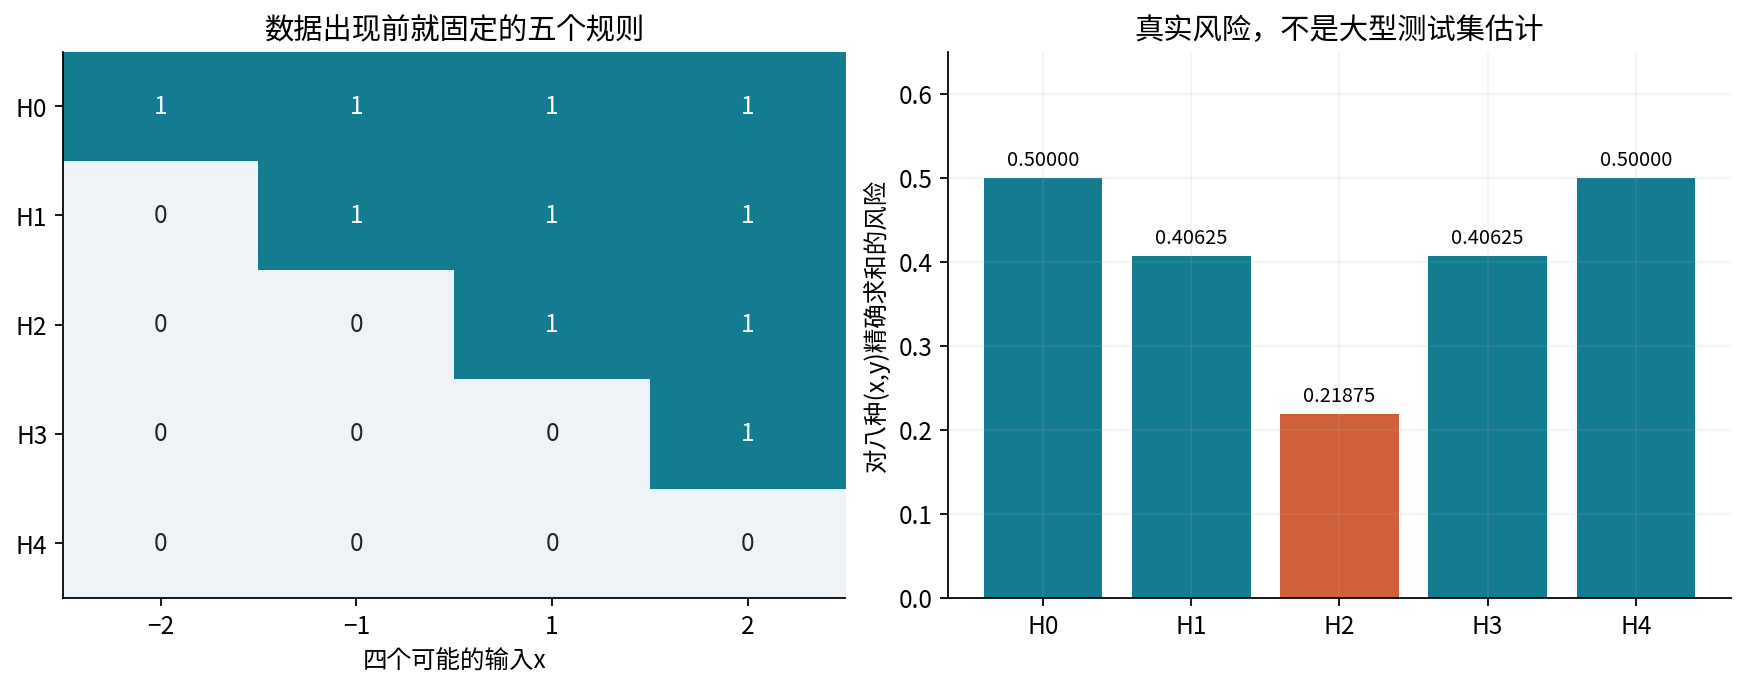

In [2]:
import os,sys,io,math
sys.path.insert(0,str(BASE))
os.environ.setdefault('MPLCONFIGDIR',str(BASE/'outputs/mpl'))
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display,Image
from fractions import Fraction
import experiment as e
import finite_class as fc
import selection as sel
import bounds,plots
from numeric import canonical_bytes,safe_write
pop,hyp,sample,cfg=e.load_inputs()
report=e.main_report(pop,hyp,sample,cfg)
def show(i):
    f=plots.figure(i,report);s=io.BytesIO()
    f.savefig(s,format='png',dpi=160,bbox_inches='tight')
    display(Image(data=s.getvalue(),format='png'));plt.close(f)
print('Full finite population:',pop)
print('Predeclared hypotheses:',hyp)
print('Population risks:',report['population'])
show(1)

## 整批前向→逐行损失→汇总→选择→下一前向
离散枚举没有梯度步骤。新增两行明确属于训练数据，不能把它们说成封存测试。

STAGE initial
{"id": "S1", "losses": [1, 0, 0, 0, 0], "mean_loss_contributions": [0.16666666666666666, 0.0, 0.0, 0.0, 0.0], "predictions": [1, 0, 0, 0, 0], "x": -2, "y": 0}
{"id": "S2", "losses": [0, 0, 1, 1, 1], "mean_loss_contributions": [0.0, 0.0, 0.16666666666666666, 0.16666666666666666, 0.16666666666666666], "predictions": [1, 1, 0, 0, 0], "x": -1, "y": 1}
{"id": "S3", "losses": [1, 1, 0, 0, 0], "mean_loss_contributions": [0.16666666666666666, 0.16666666666666666, 0.0, 0.0, 0.0], "predictions": [1, 1, 0, 0, 0], "x": -1, "y": 0}
{"id": "S4", "losses": [0, 0, 0, 1, 1], "mean_loss_contributions": [0.0, 0.0, 0.0, 0.16666666666666666, 0.16666666666666666], "predictions": [1, 1, 1, 0, 0], "x": 1, "y": 1}
{"id": "S5", "losses": [0, 0, 0, 0, 1], "mean_loss_contributions": [0.0, 0.0, 0.0, 0.0, 0.16666666666666666], "predictions": [1, 1, 1, 1, 0], "x": 2, "y": 1}
{"id": "S6", "losses": [1, 1, 1, 1, 0], "mean_loss_contributions": [0.16666666666666666, 0.16666666666666666, 0.16666666666666666

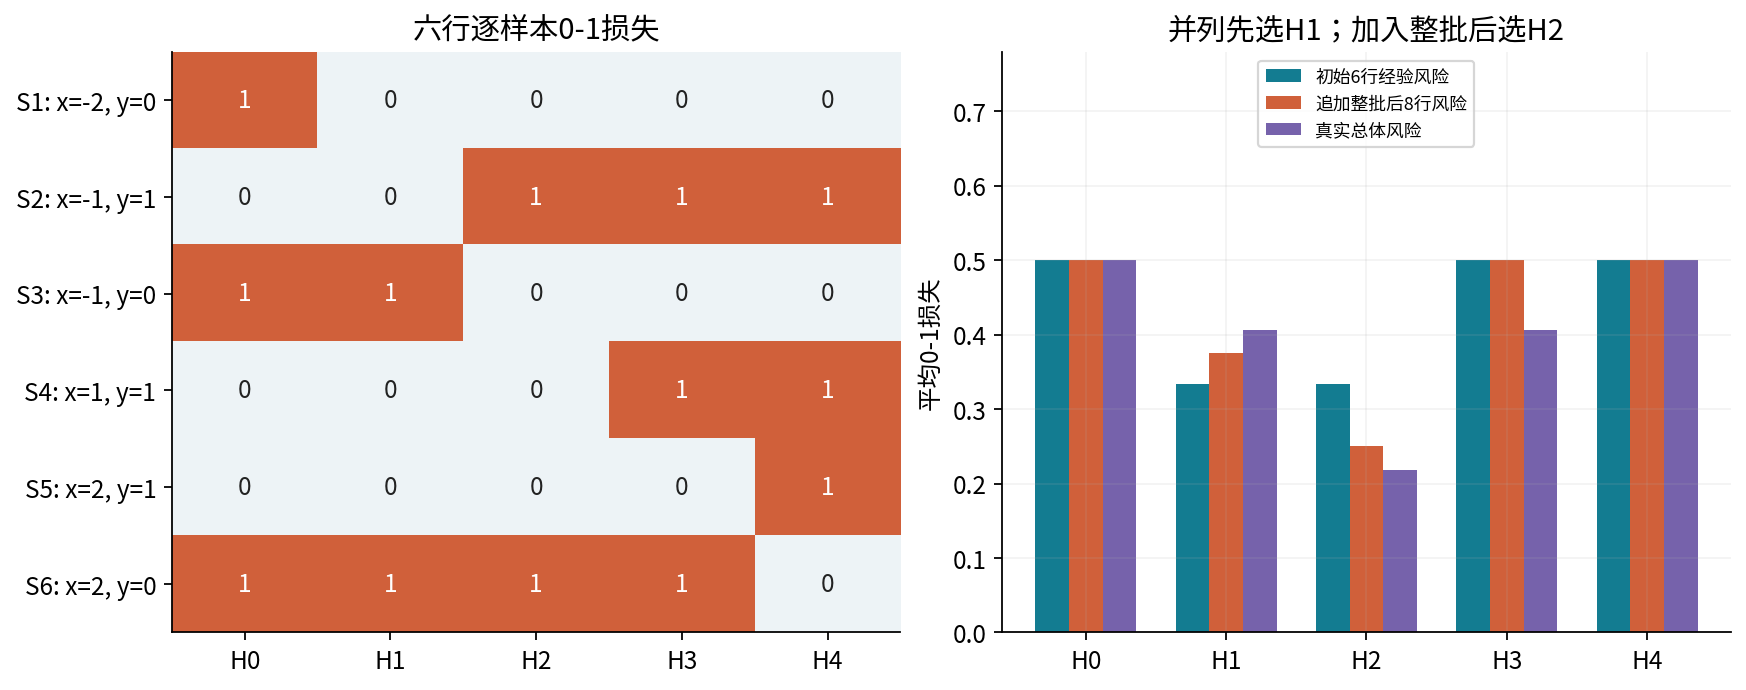

In [3]:
for stage in ['initial','after_batch']:
    value=report['hand'][stage]
    print('STAGE',stage)
    for row in value['rows']: print(json.dumps(row,sort_keys=True))
    for key in ['sample_size','loss_counts','empirical_risks','population_risk_fractions','tie_indices','selected_index','selected_id']:
        print(key,value[key])
print('Next forward:',report['hand']['next_forward_on_all_four_inputs'])
print('Optimization definition:',report['hand']['initial']['optimization'])
show(2)

## 公式不是无条件承诺
Hoeffding需要观测独立、有界损失；union bound不需要候选模型独立。

In [4]:
for n,M in [(8,5),(20,1),(20,512),(100,512)]:
    print('n,M,delta,radius:',n,M,.05,bounds.radius(n,.05,M))
print('Exact tail bound example:',bounds.tail(8,.5,5))
for label,operation in [
    ('bool n',lambda:bounds.radius(True,.05)),
    ('delta0',lambda:bounds.radius(20,0)),
    ('complex delta',lambda:bounds.radius(20,.05+0j)),
    ('invalid unused candidate column',lambda:sel.choose([[0,21]],20,1))]:
    try:operation()
    except ValueError as ex:print('Expected rejection:',label,str(ex))
    else:raise RuntimeError('Invalid input accepted: '+label)

n,M,delta,radius: 8 5 0.05 0.5754518532503412
n,M,delta,radius: 20 1 0.05 0.3036807309541526
n,M,delta,radius: 20 512 0.05 0.49817677783979064
n,M,delta,radius: 100 512 0.05 0.22279142801231652
Exact tail bound example: {'raw_bound': 0.18315638888734176, 'probability_bound': 0.18315638888734176, 'log_raw_bound': -1.6974149070059545, 'vacuous': False, 'assumptions': 'fixed finite hypothesis class; independent identically distributed observations; losses in [0,1]'}
Expected rejection: bool n sample size requires a real scalar, not bool/string/complex
Expected rejection: delta0 failure probability outside supported finite raw range
Expected rejection: complex delta failure probability requires a real scalar, not bool/string/complex
Expected rejection: invalid unused candidate column candidate error count outside supported finite raw range


EXACT ENUMERATION {"composition_states": 36, "expected_excess_risk_fraction": "20871/131072", "expected_optimism_fraction": "39463/131072", "expected_selected_risk": 0.37798309326171875, "expected_selected_risk_fraction": "49543/131072", "expected_training_risk": 0.076904296875, "expected_training_risk_fraction": "315/4096", "expected_uniform_gap": 0.4547882080078125, "expected_uniform_gap_fraction": "29805/65536", "n": 2, "ordered_sequence_count": 64, "selection_probability_fractions": ["827/2048", "483/4096", "369/1024", "105/1024", "63/4096"], "tails": [{"epsilon": "1/8", "fixed_Hoeffding": {"assumptions": "fixed finite hypothesis class; independent identically distributed observations; losses in [0,1]", "log_raw_bound": 0.6306471805599453, "probability_bound": 1.0, "raw_bound": 1.8788261256269516, "vacuous": true}, "fixed_tail_fraction": "1", "fixed_tail_probability": 1.0, "uniform_Hoeffding_union": {"assumptions": "fixed finite hypothesis class; independent identically distributed

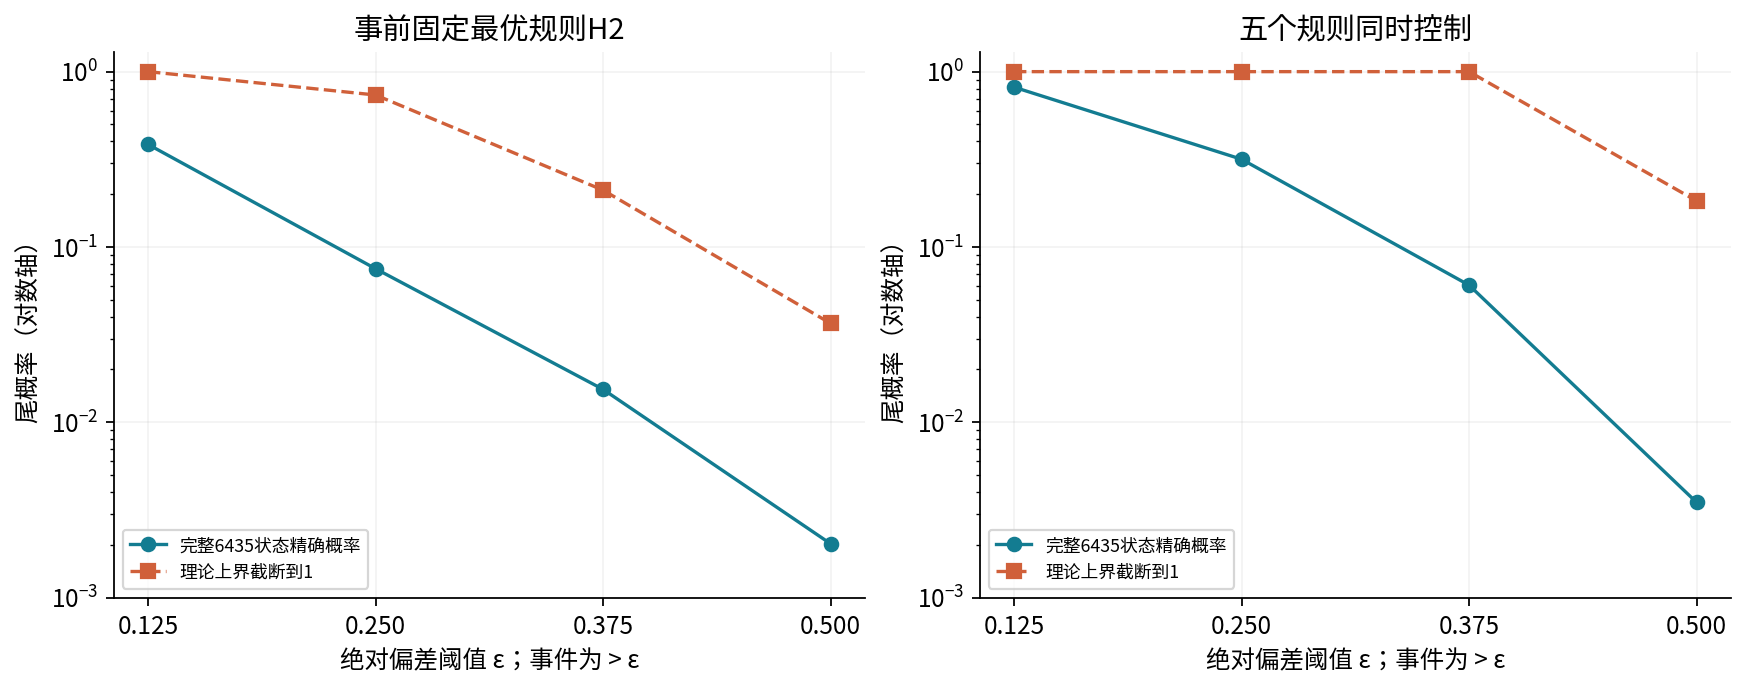

In [5]:
for block in report['exact']:
    print('EXACT ENUMERATION',json.dumps(block,ensure_ascii=False,sort_keys=True))
print('n=4 ordered sequences:',8**4,'compositions:',math.comb(11,7))
print('n=8 ordered sequences:',8**8,'compositions:',math.comb(15,7))
show(3)

## 14000次IID主重复
完整计数留在report和最后输出JSON；这里展示每个n的前3次与完整汇总，避免将大量重复文本当作教学深度。

N= 8 uniform radius= 0.5754518532503412
First3 actual records: [{'repetition': 0, 'category_counts': [0, 1, 6, 0, 0, 1, 0, 0], 'chosen_index': 2, 'selected_training_risk': 0.125, 'selected_population_risk': 0.21875, 'signed_optimism': 0.09375, 'excess_risk': 0.0, 'uniform_absolute_gap': 0.46875, 'predeclared_best_absolute_gap': 0.09375}, {'repetition': 1, 'category_counts': [2, 0, 2, 0, 1, 2, 0, 1], 'chosen_index': 2, 'selected_training_risk': 0.125, 'selected_population_risk': 0.21875, 'signed_optimism': 0.09375, 'excess_risk': 0.0, 'uniform_absolute_gap': 0.15625, 'predeclared_best_absolute_gap': 0.09375}, {'repetition': 2, 'category_counts': [2, 0, 3, 0, 0, 3, 0, 0], 'chosen_index': 2, 'selected_training_risk': 0.0, 'selected_population_risk': 0.21875, 'signed_optimism': 0.21875, 'excess_risk': 0.0, 'uniform_absolute_gap': 0.21875, 'predeclared_best_absolute_gap': 0.21875}]
All summaries: {"excess_risk": {"max": 0.28125, "mc_standard_error": 0.002442667556563548, "mean": 0.078796875

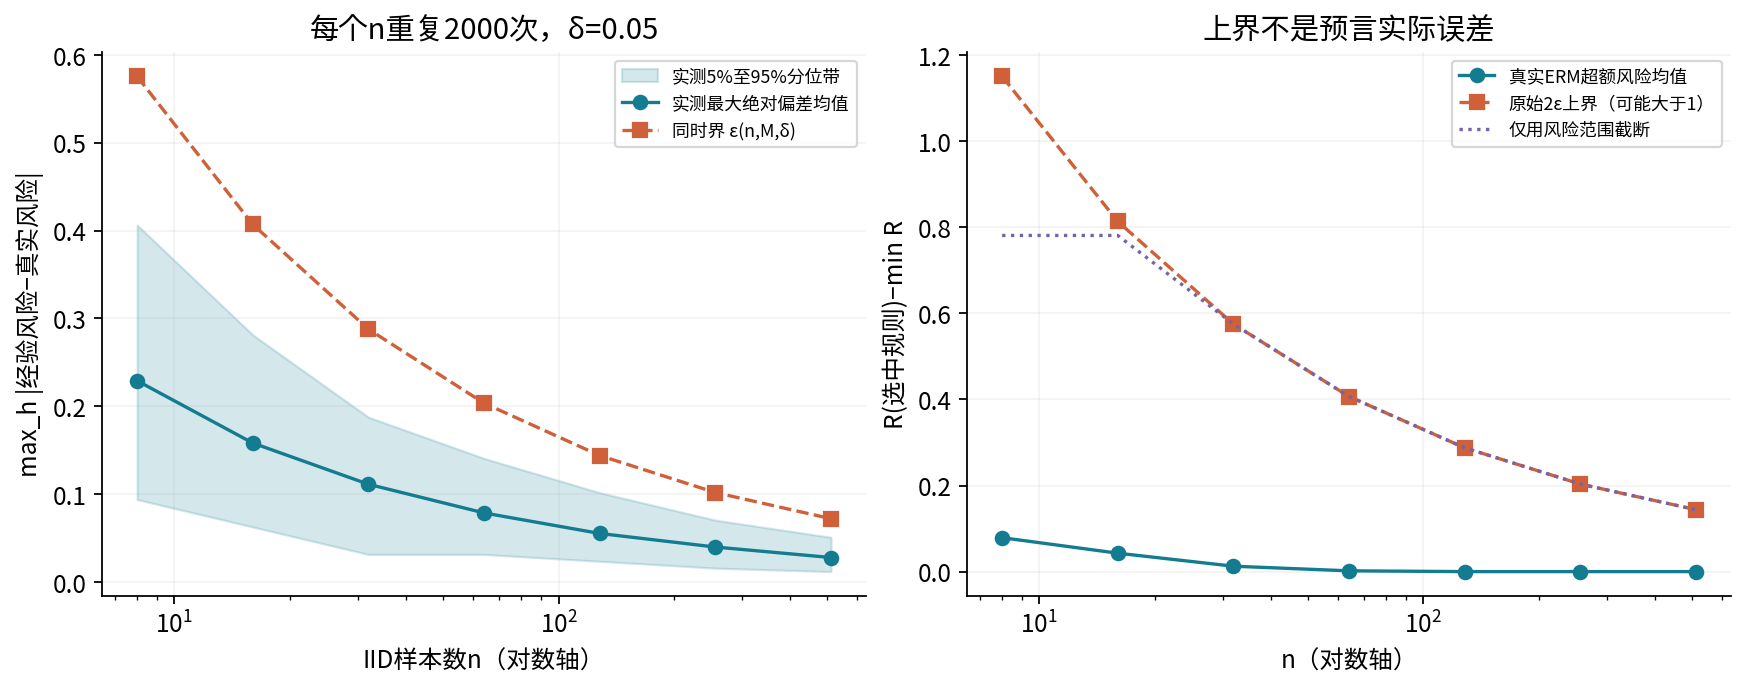

In [6]:
for block in report['main_repetitions']:
    print('N=',block['n'],'uniform radius=',block['uniform_radius'])
    print('First3 actual records:',block['records'][:3])
    print('All summaries:',json.dumps(block['summary'],sort_keys=True))
    print('Violation counts:',json.dumps(block['violations'],sort_keys=True))
    if len(block['records'])!=cfg['main_repetitions']:raise RuntimeError('Missing repeated records')
show(4)

## 纯噪声筛选：每个规则真实风险都为1/2
候选间独立是此特定反例的构造，用于解析分布计算；不是union bound额外要求。

NOISE SAMPLE SIZE 20
M= 1 mean train risk= 0.49772500000000003
Misused fixed radius events: {'count': 6, 'repetitions': 2000, 'frequency': 0.003, 'binomial_mc_standard_error': 0.0012229063741758812, 'zero_events_one_sided_95_upper': None, 'zero_note': 'zero observed violations do not establish a theorem; upper bound assumes independent repeated experiments'}
Correct uniform radius events: {'count': 6, 'repetitions': 2000, 'frequency': 0.003, 'binomial_mc_standard_error': 0.0012229063741758812, 'zero_events_one_sided_95_upper': None, 'zero_note': 'zero observed violations do not establish a theorem; upper bound assumes independent repeated experiments'}
Analytic probabilities: {'n': 20, 'M': 1, 'precision_decimal_digits': 100, 'fixed_radius_decimal': '0.3036807309541525842961854022165462124812512125131499735333732860226179404664720237149827259541314630', 'uniform_radius_decimal': '0.3036807309541525842961854022165462124812512125131499735333732860226179404664720237149827259541314630', 's

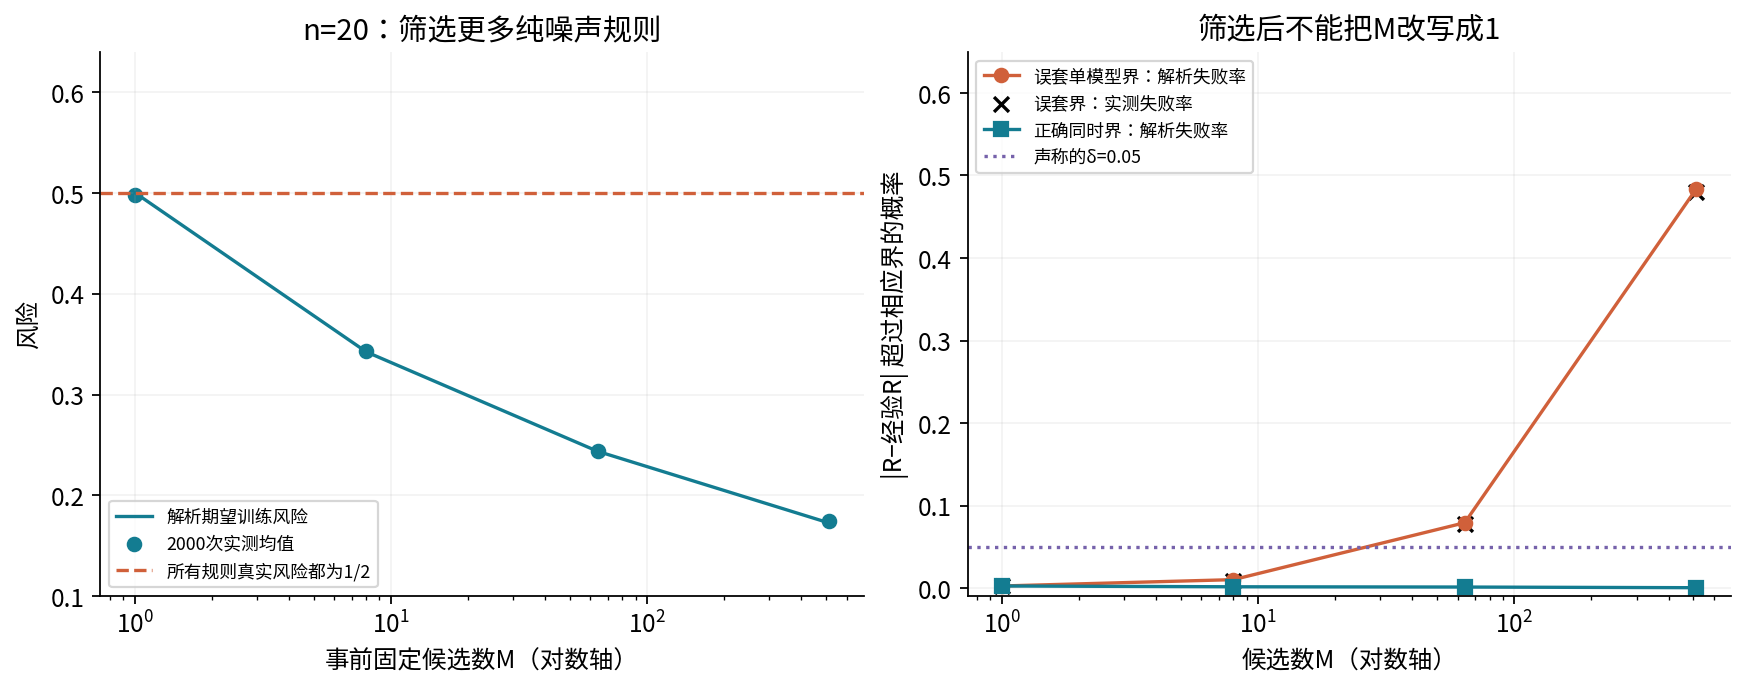

In [7]:
for block in report['selection_noise']:
    print('NOISE SAMPLE SIZE',block['n'])
    for scenario in block['scenarios']:
        print('M=',scenario['M'],'mean train risk=',scenario['mean_training_risk'])
        print('Misused fixed radius events:',scenario['fixed_radius_violations'])
        print('Correct uniform radius events:',scenario['uniform_radius_violations'])
        print('Analytic probabilities:',{k:v for k,v in scenario['analytic'].items() if k!='minimum_pmf'})
        print('First8 chosen indices/counts:',scenario['selection']['selected_indices'][:8],scenario['selection']['selected_error_counts'][:8])
q=Fraction(sum(math.comb(20,k) for k in range(4)),2**20)
print('Exact single lower-tail q=',str(q),'float=',float(q))
show(5)

M= 1 analytic minimum PMF: [9.5367431640625e-07, 1.9073486328125e-05, 0.0001811981201171875, 0.001087188720703125, 0.004620552062988281, 0.0147857666015625, 0.03696441650390625, 0.0739288330078125, 0.12013435363769531, 0.16017913818359375, 0.17619705200195312, 0.16017913818359375, 0.12013435363769531, 0.0739288330078125, 0.03696441650390625, 0.0147857666015625, 0.004620552062988281, 0.001087188720703125, 0.0001811981201171875, 1.9073486328125e-05, 9.5367431640625e-07]
Actual minimum count histogram: [0, 0, 1, 3, 6, 29, 79, 154, 258, 326, 337, 288, 268, 145, 68, 23, 13, 1, 1, 0, 0]
M= 8 analytic minimum PMF: [7.629369065446923e-06, 0.000152576686100042, 0.0014484628819166497, 0.008652282355777259, 0.03604460138603899, 0.10774439148962851, 0.22413082840482373, 0.2983696413707652, 0.22516118839412141, 0.08397967957627511, 0.013480114575333548, 0.0008124831765744958, 1.603043976317445e-05, 8.977165168309824e-08, 1.221310874121337e-10, 3.364026261906587e-14, 1.4862427447040722e-18, 7.593523

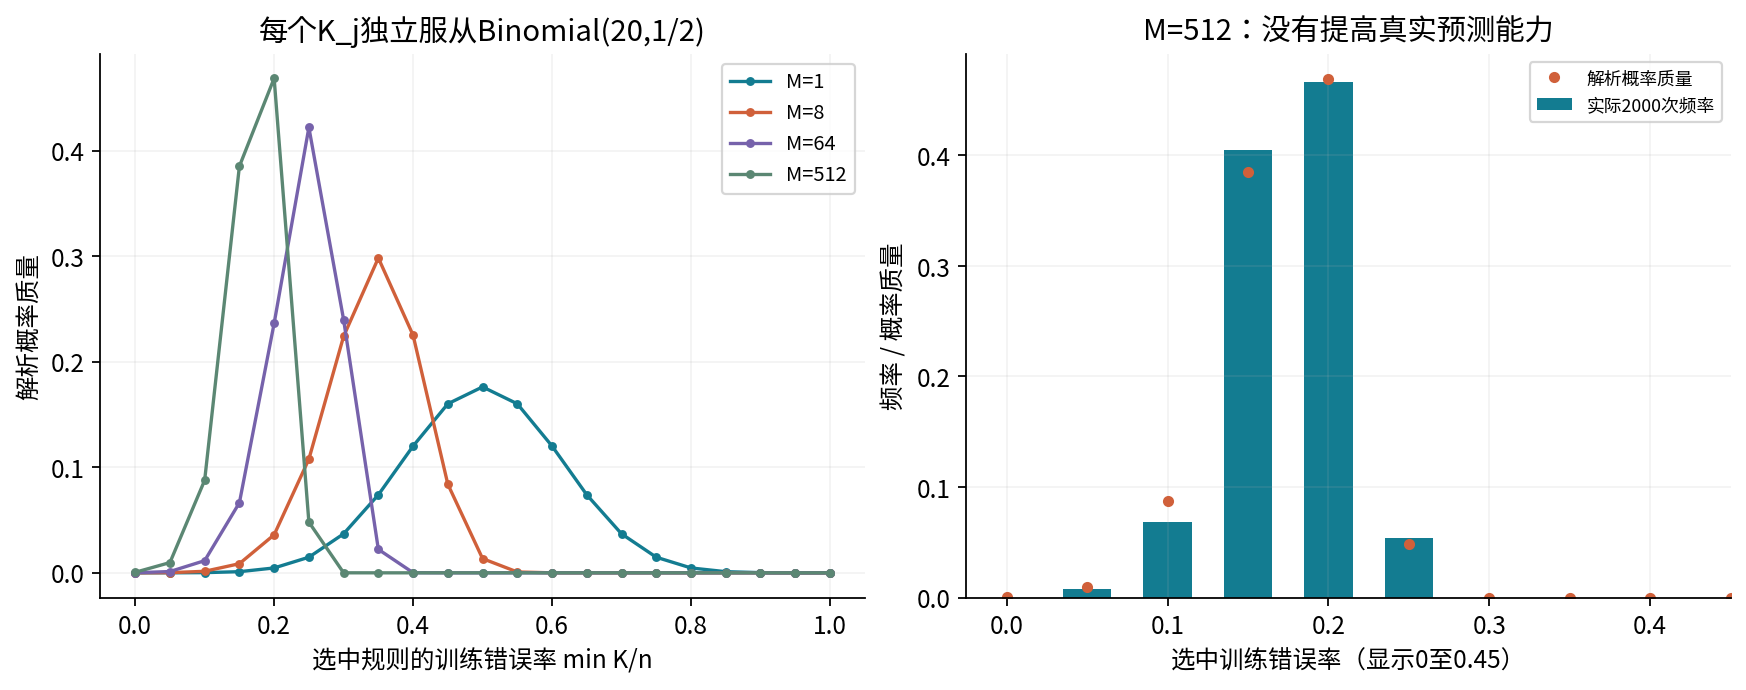

In [8]:
for scenario in report['selection_noise'][0]['scenarios']:
    print('M=',scenario['M'],'analytic minimum PMF:',scenario['analytic']['minimum_pmf'])
    print('Actual minimum count histogram:',scenario['selected_error_count_histogram'])
    if sum(scenario['selected_error_count_histogram'])!=cfg['noise_repetitions']:
        raise RuntimeError('Histogram count mismatch')
show(6)

## PAC样本量公式：两个不同前提
右图可实现一致学习器的结论不能直接用在有噪声主总体。

{"M": 1, "agnostic": {"assumptions": "exact ERM over fixed finite class, IID [0,1] losses; no realizability assumed", "derivation": "uniform radius <= epsilon/2 implies ERM excess risk <= epsilon", "sufficient_sample_size": 2952, "unrounded": 2951.1035632911485}, "epsilon": 0.05, "realizable": {"assumptions": "IID binary classification, fixed finite H contains a zero-risk rule, learner returns a consistent rule", "sufficient_sample_size": 60, "unrounded": 59.914645471079815, "warning": "not applicable to the noisy default finite population"}}
{"M": 5, "agnostic": {"assumptions": "exact ERM over fixed finite class, IID [0,1] losses; no realizability assumed", "derivation": "uniform radius <= epsilon/2 implies ERM excess risk <= epsilon", "sufficient_sample_size": 4239, "unrounded": 4238.653893238428}, "epsilon": 0.05, "realizable": {"assumptions": "IID binary classification, fixed finite H contains a zero-risk rule, learner returns a consistent rule", "sufficient_sample_size": 93, "unro

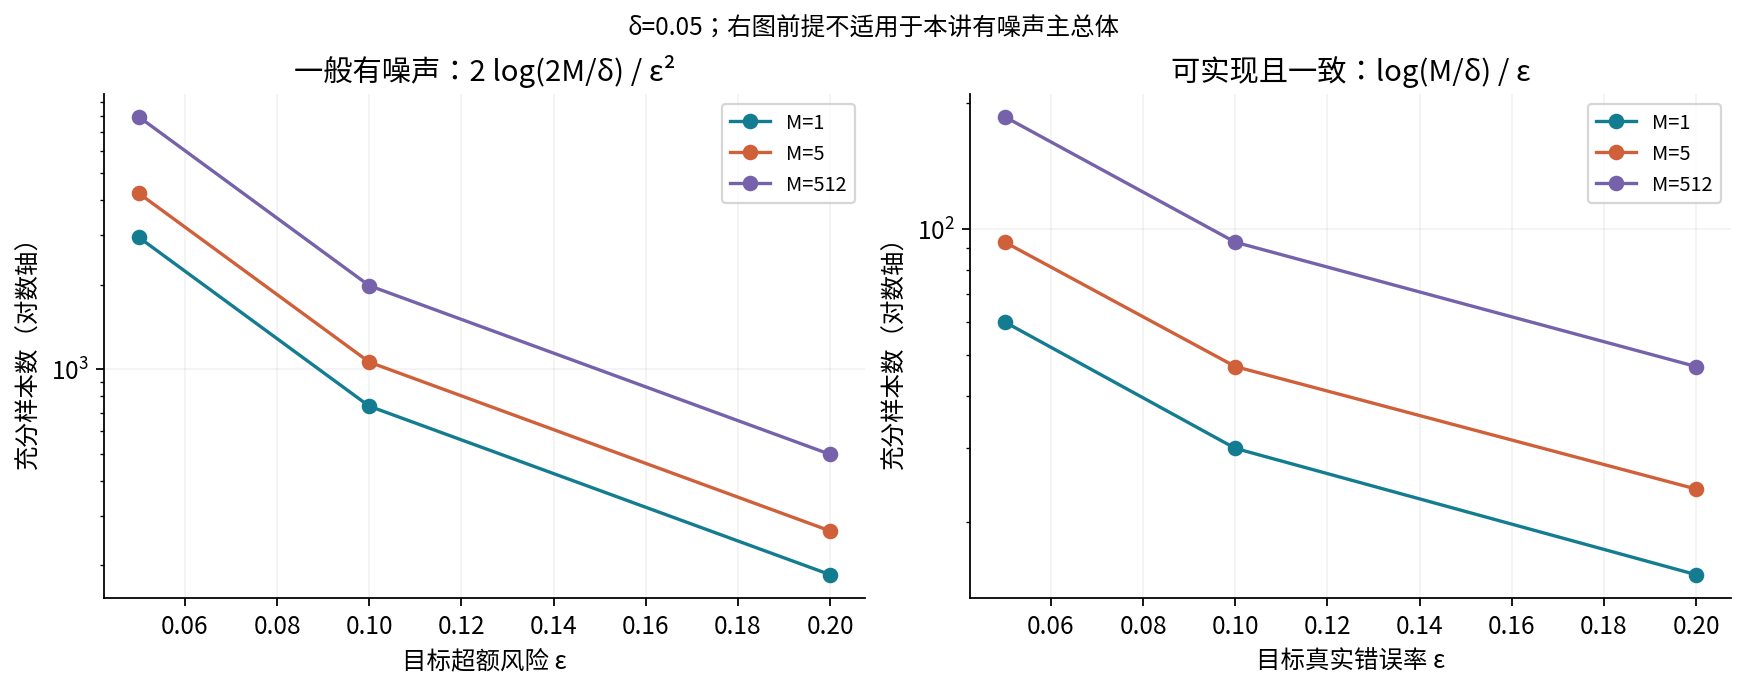

In [9]:
for row in report['sample_complexity_table']:print(json.dumps(row,sort_keys=True))
print('Main population minimum risk:',report['population']['minimum_risk'])
print('Realizable zero-risk premise holds?',report['population']['minimum_risk']==0)
show(7)

DEPENDENCE COUNTEREXAMPLE: {"absolute_gap_always": 0.5, "actual_independent_bits": 1, "marginal_true_risk": 0.5, "misused_IID_radius": 0.3036807309541526, "misused_IID_violation_probability": 1.0, "nominal_n": 20, "outcome_probabilities": [0.5, 0.5], "possible_empirical_risks": [0.0, 1.0], "reason": "all n loss values are exact copies of one fair Bernoulli bit; identical marginals without independence"}
Single bit, copied mean, absolute gap: 0 0.0 0.5
Single bit, copied mean, absolute gap: 1 1.0 0.5


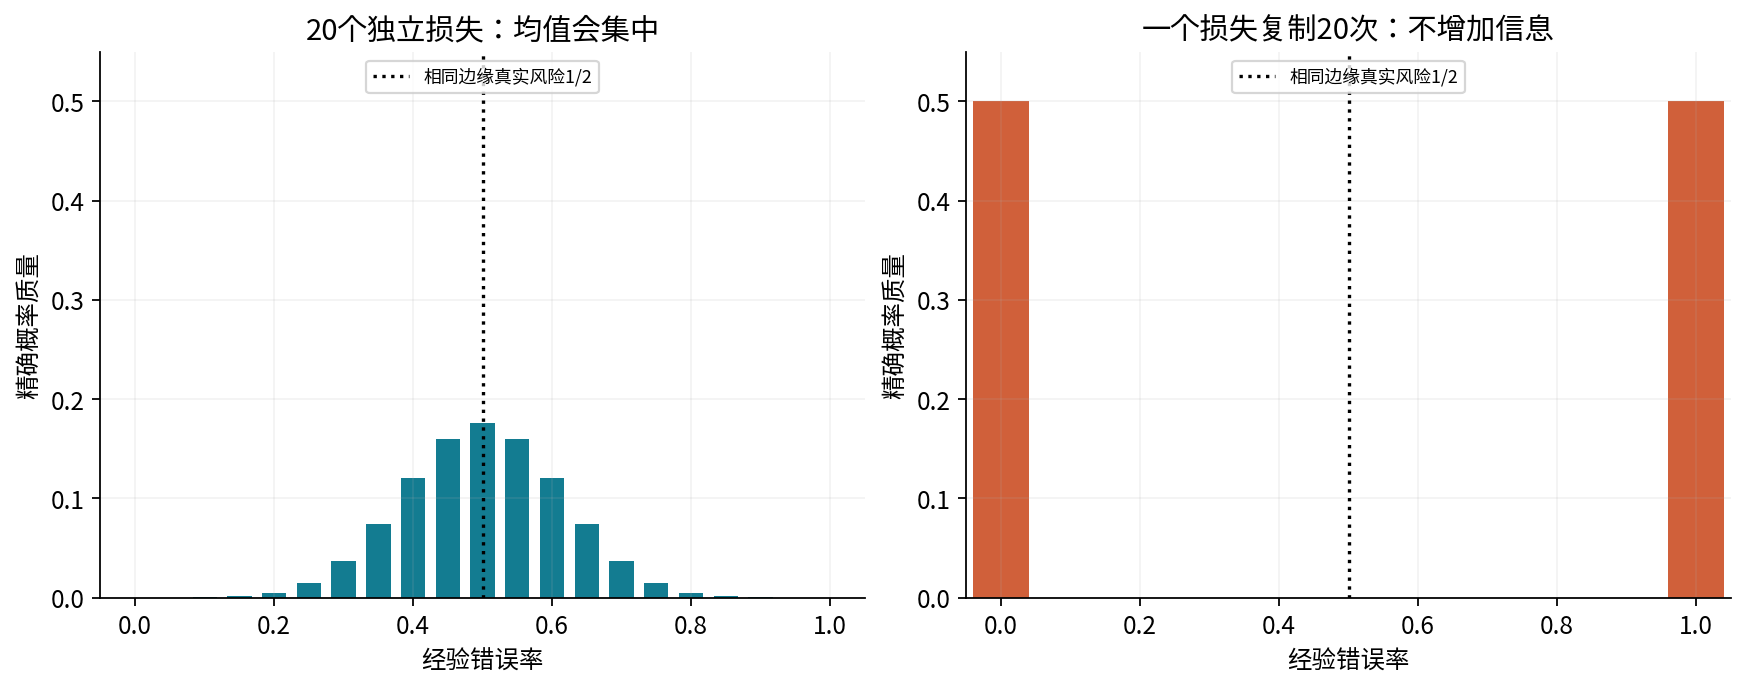

In [10]:
print('DEPENDENCE COUNTEREXAMPLE:',json.dumps(report['dependence_counterexample'],sort_keys=True))
for bit in [0,1]:
    copied=np.repeat(bit,cfg['dependent_repeat_count'])
    print('Single bit, copied mean, absolute gap:',bit,float(copied.mean()),abs(float(copied.mean())-.5))
show(8)

## 独立留出：先冻结选择再生成评价结果
训练侧和留出侧按各自样本数算半径，不能把不同数据角色混成一个分数。

Training n= 20 holdout: {'n': 100, 'selected_from_M': 512, 'training_choice_sha256': 'bee8447f708e002c19f38a56d497a9aa4d8e1d1aeeed8f301918c1176bc795fe', 'fixed_radius': 0.13581015157406195, 'violations': {'count': 14, 'repetitions': 2000, 'frequency': 0.007, 'binomial_mc_standard_error': 0.0018642692938521516, 'zero_events_one_sided_95_upper': None, 'zero_note': 'zero observed violations do not establish a theorem; upper bound assumes independent repeated experiments'}, 'true_risk': 0.5, 'scope': 'conditional on training-selected index, fresh independent holdout errors are Binomial(n_holdout,1/2); no holdout feedback to selection'}
First10 holdout error counts: [45, 53, 58, 48, 55, 46, 48, 46, 55, 50]
Training n= 50 holdout: {'n': 100, 'selected_from_M': 512, 'training_choice_sha256': 'e9f90f6c197f7fdb4bd80e7c9f9ad17494ff2d5216504b85621c3b3d2d578827', 'fixed_radius': 0.13581015157406195, 'violations': {'count': 15, 'repetitions': 2000, 'frequency': 0.0075, 'binomial_mc_standard_error':

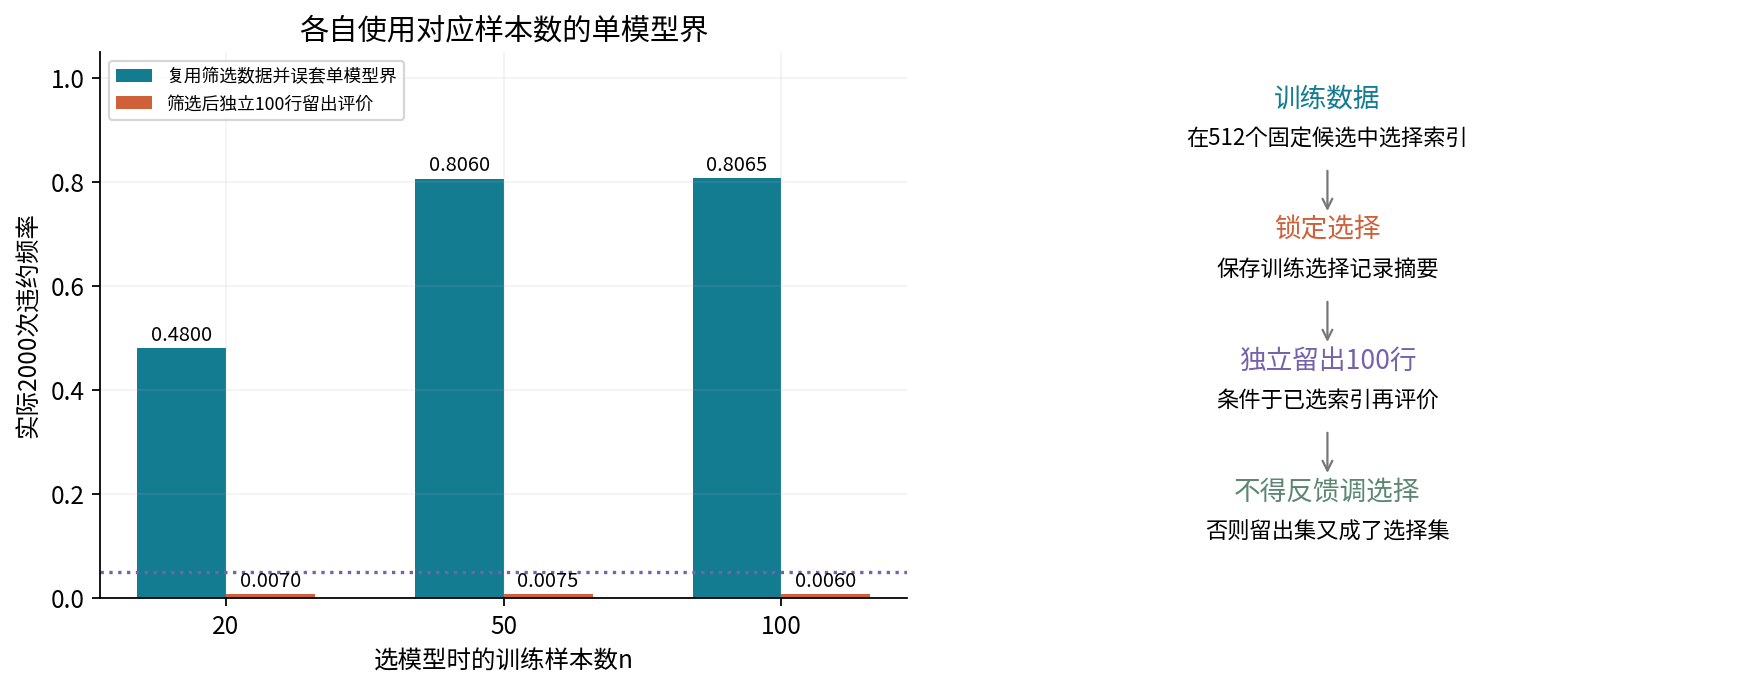

In [11]:
for block in report['selection_noise']:
    holdout=block['independent_holdout']
    print('Training n=',block['n'],'holdout:',{k:v for k,v in holdout.items() if k!='error_counts'})
    print('First10 holdout error counts:',holdout['error_counts'][:10])
    frozen=block['scenarios'][-1]['selection']
    if hashlib.sha256(canonical_bytes(frozen)).hexdigest()!=holdout['training_choice_sha256']:
        raise RuntimeError('Choice hash differs')
print('Standalone choice API has no holdout argument:',sel.choose([[3,2,5],[1,1,4]],20,3))
show(9)

POINT COUNT 1 counts 2 2 2
Threshold patterns/missing: [[0], [1]] []
Interval patterns/missing: [[0], [1]] []
POINT COUNT 2 counts 3 4 4
Threshold patterns/missing: [[0, 0], [0, 1], [1, 1]] [[1, 0]]
Interval patterns/missing: [[0, 0], [0, 1], [1, 0], [1, 1]] []
POINT COUNT 3 counts 4 7 8
Threshold patterns/missing: [[0, 0, 0], [0, 0, 1], [0, 1, 1], [1, 1, 1]] [[0, 1, 0], [1, 0, 0], [1, 0, 1], [1, 1, 0]]
Interval patterns/missing: [[0, 0, 0], [0, 0, 1], [0, 1, 0], [0, 1, 1], [1, 0, 0], [1, 1, 0], [1, 1, 1]] [[1, 0, 1]]
POINT COUNT 4 counts 5 11 16
POINT COUNT 5 counts 6 16 32
Scope: all real thresholds with fixed increasing direction and all real closed intervals; these are separate example classes, not a shortcut substituting growth into a fixed-class union bound


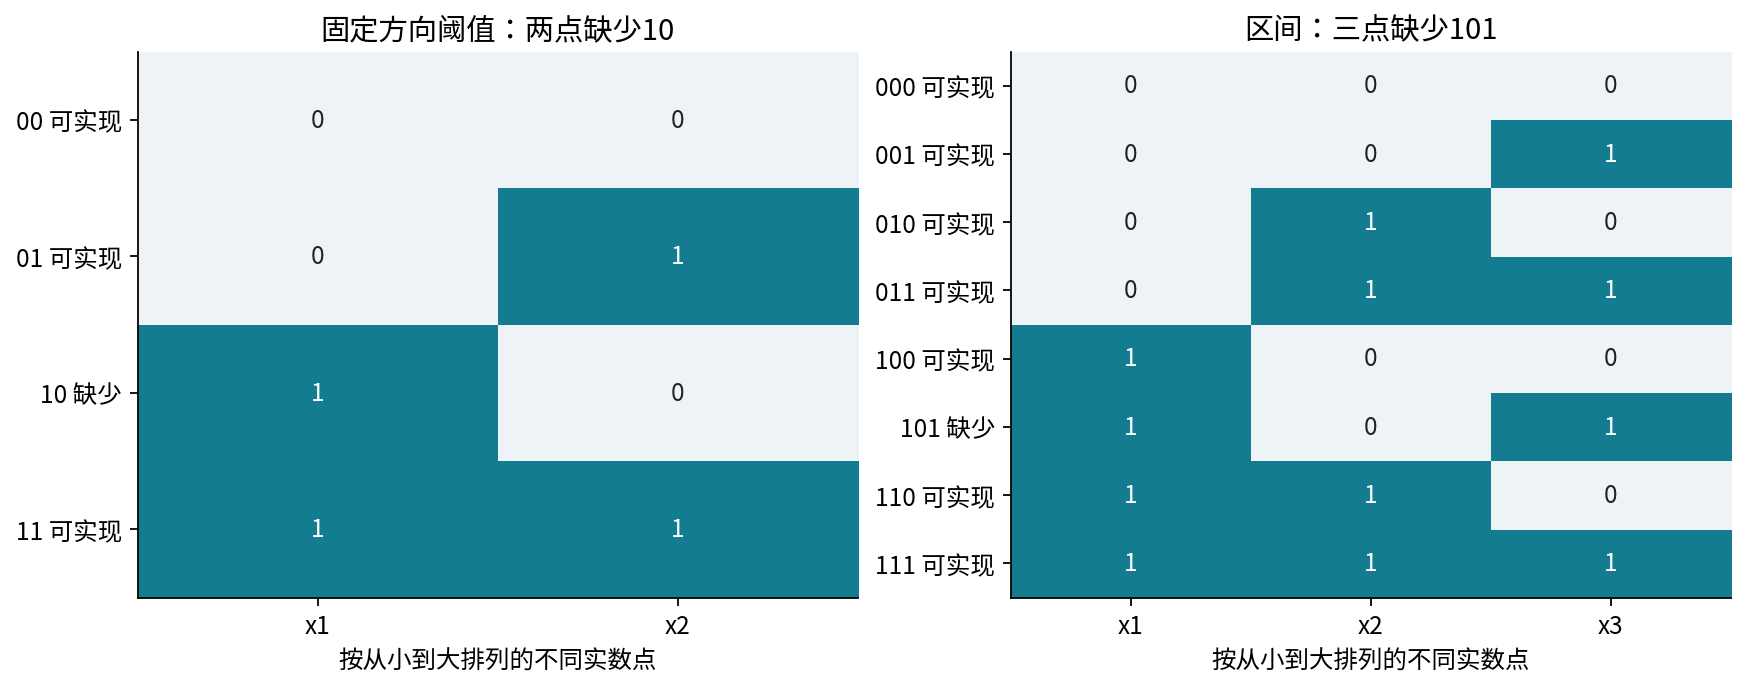

In [12]:
for row in report['vc']['ordered_distinct_point_patterns']:
    print('POINT COUNT',row['points'],'counts',row['threshold_count'],row['interval_count'],row['all_labelings'])
    if row['points']<=3:
        print('Threshold patterns/missing:',row['threshold_patterns'],row['threshold_missing'])
        print('Interval patterns/missing:',row['interval_patterns'],row['interval_missing'])
print('Scope:',report['vc']['scope'])
show(10)

## 独立核验与全部结果
4096条有序序列、精确二项尾概率、Decimal、实际SciPy分布与随机流重建。Monte Carlo偏离解析值记录为诊断，不调整种子或用随意门槛筛结果。

In [13]:
import audit
checks=audit.audit()
print(json.dumps(checks,ensure_ascii=False,sort_keys=True))
science_hash=hashlib.sha256(canonical_bytes(report)).hexdigest()
if checks['core_sha256']!=science_hash:raise RuntimeError('Notebook and script differ')
safe_write(BASE/'outputs/notebook-result.json',report)
print('Saved every repeated record. Scientific SHA256:',science_hash)

{"VC": {"all_ordered_pattern_counts_verified": true, "interval_VC": 2, "threshold_VC": 1}, "bounds": {"Decimal80_radius_examples": [{"M": 1, "delta": 0.05, "n": 1, "radius": 1.3581015157406195}, {"M": 512, "delta": 0.05, "n": 20, "radius": 0.49817677783979064}, {"M": 5, "delta": 1e-12, "n": 1000, "radius": 0.12233888631363822}, {"M": 1048576, "delta": 0.2, "n": 1000000, "radius": 0.0028430202869653386}], "sample_requirement_inversions_checked": true}, "core_sha256": "dbb5d325609935cf1c301f2b1180a396da575ff814c65b0518384b9ae578c360", "dependence_failure_probability": 1.0, "exact": {"all_fixed_Binomial_tails_and_event_union_checked": true, "exact_composition_n": [2, 4, 6, 8], "ordered_sequences_checked": 4096, "population_risk_fractions": ["1/2", "13/32", "7/32", "13/32", "1/2"]}, "guards": {"all_config_fields_and_loaded_last_values_precompute_checked": true, "atomic_output_and_aliases_checked": true, "numeric_integer_bool_complex_domain_checked": true}, "hand": {"full_forward_loss_chain

Saved every repeated record. Scientific SHA256: dbb5d325609935cf1c301f2b1180a396da575ff814c65b0518384b9ae578c360
